
# CNN Transfer Baseline — DeepFakeDetector

**Goal:** Fine-tune a pretrained CNN to classify images as **Real** vs **AI-generated** (deepfakes).  
This notebook is a **beginner-friendly, end-to-end baseline** that you can run locally or in Colab.

**Backbones supported:** `EfficientNet-B0` (default) and `ResNet-50` (toggle below).  
**Metrics:** Accuracy, F1, AUROC.  
**Extras:** Optional saliency map for interpretability, model checkpointing, and clear instructions.

> ✅ This file is the deliverable requested by the issue: `notebooks/cnn_transfer_baseline.ipynb`.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



## 0. Setup

- You need Python 3.10+ recommended.
- If running the notebook locally, install dependencies with the cell below.
- If running in **Google Colab**, the cell will also work; GPU is recommended.

> Dataset (expected folder structure):
```
data/
  train/
    real/
    fake/
  val/
    real/
    fake/
```
- Each folder contains images (JPG/PNG). You may rename `fake` to `ai` if you like—just update the `CLASS_NAMES` below.


In [4]:
!apt-get update -qq
!apt-get install -y -qq unzip
!unzip -q -o /content/datasets.zip -d /content
!find /content/datasets -maxdepth 3 -type d -print

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
unzip:  cannot find or open /content/datasets.zip, /content/datasets.zip.zip or /content/datasets.zip.ZIP.
find: ‘/content/datasets’: No such file or directory


In [5]:

# If you are on Colab or a fresh environment, uncomment and run:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install scikit-learn matplotlib tqdm pillow captum


In [6]:
# =========================
# CELL 1: Imports + config
# =========================
import os, time, copy, math, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ---- Beginner-friendly switches ----
USE_MODEL = "efficientnet_b0"   # issue wants EfficientNet-B0 baseline
FREEZE_BACKBONE = True
UNFREEZE_EPOCH = 3              # set None to keep frozen
NUM_EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

IM_SIZE = 224

# Enforced label mapping for all datasets/splits
# Required by issue: 0=real, 1=fake
LABEL_MAP = {"real": 0, "fake": 1}

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


Using device: cuda


In [7]:
# =========================
# CELL 2: Reproducibility
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic can reduce speed but improves reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed set.")


Seed set.



## 1. Data Loading and Augmentations

- We use `ImageFolder` so the folder names define classes.
- Basic augmentations help generalization.


In [8]:
# ==========================================
# CELL 3 (UPDATED AGAIN): Drive paths + transforms + datasets + loaders
# Fixes:
# - no slow copy step
# - safer PIL loading
# - immediate sanity check
# ==========================================
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import ImageFile

# Allow loading truncated/corrupted images without hanging
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------- Settings --------
IM_SIZE = 224
BATCH_SIZE = 16          # lower batch to reduce chance of stalls/OOM
NUM_WORKERS = 0          # safest for Colab + Drive
PIN_MEMORY = False

LABEL_MAP = {"real": 0, "fake": 1}  # required: 0=real, 1=fake

# -------- Paths (Drive) --------
DRIVE_ROOT = Path("/content/drive/MyDrive")
DATASETS_ROOT = DRIVE_ROOT / "datasets"

DATASET_A_DIR = DATASETS_ROOT / "OpenFake"
TRAIN_SPLIT_A = "train"
VAL_SPLIT_A   = "test"

train_dir = DATASET_A_DIR / TRAIN_SPLIT_A
val_dir   = DATASET_A_DIR / VAL_SPLIT_A

# -------- Checks --------
assert train_dir.exists(), f"Missing folder: {train_dir}"
assert val_dir.exists(), f"Missing folder: {val_dir}"
for d in [train_dir, val_dir]:
    assert (d / "real").exists() and (d / "fake").exists(), \
        f"{d} must contain subfolders real/ and fake/"

# -------- Transforms --------
train_tfms = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -------- Dataset with fixed label mapping --------
def imagefolder_fixed_labels(root: Path, transform):
    ds = datasets.ImageFolder(root, transform=transform)

    old_to_new = {}
    for cls_name, old_idx in ds.class_to_idx.items():
        if cls_name not in LABEL_MAP:
            raise ValueError(f"Unexpected class folder '{cls_name}'. Expected {list(LABEL_MAP.keys())}")
        old_to_new[old_idx] = LABEL_MAP[cls_name]

    ds.targets = [old_to_new[y] for y in ds.targets]
    ds.samples = [(p, old_to_new[y]) for (p, y) in ds.samples]

    ds.classes = ["real", "fake"]
    ds.class_to_idx = {"real": 0, "fake": 1}
    return ds

train_ds = imagefolder_fixed_labels(train_dir, transform=train_tfms)
val_ds   = imagefolder_fixed_labels(val_dir,   transform=val_tfms)

print("Fixed class_to_idx:", train_ds.class_to_idx)
print(f"Train images: {len(train_ds)}  |  Val images: {len(val_ds)}")

# -------- DataLoaders --------
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

FAKE_IDX = 1
REAL_IDX = 0

# -------- Hard sanity check: pull 2 batches --------
for i, (imgs, labels) in enumerate(train_loader):
    print("Batch", i, imgs.shape, "labels unique:", labels.unique().tolist())
    if i >= 1:
        break
print("DataLoader OK.")


Fixed class_to_idx: {'real': 0, 'fake': 1}
Train images: 8987  |  Val images: 1000
Batch 0 torch.Size([16, 3, 224, 224]) labels unique: [0, 1]
Batch 1 torch.Size([16, 3, 224, 224]) labels unique: [0, 1]
DataLoader OK.



## 2. Build the Model (Transfer Learning)

Pick a pretrained backbone and replace the classification head with a 2‑class head.


In [9]:
# =========================
# CELL 4: Build model + loss + optimizer
# (EfficientNet-B0 default, supports ResNet50 toggle)
# =========================
import torch
import torch.nn as nn
import torch.optim as optim

def build_model(name: str, num_classes: int = 2, freeze_backbone: bool = True):
    if name == "efficientnet_b0":
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        backbone_modules = [model.features]

    elif name == "resnet50":
        from torchvision.models import resnet50, ResNet50_Weights
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        backbone_modules = [model.conv1, model.layer1, model.layer2, model.layer3, model.layer4]

    else:
        raise ValueError(f"Unknown model: {name}. Use 'efficientnet_b0' or 'resnet50'.")

    if freeze_backbone:
        for m in backbone_modules:
            for p in m.parameters():
                p.requires_grad = False

    return model

# ---- use your config from Cell 1 ----
# USE_MODEL, FREEZE_BACKBONE, LR, WEIGHT_DECAY, DEVICE must already exist

model = build_model(USE_MODEL, num_classes=2, freeze_backbone=FREEZE_BACKBONE).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model: {USE_MODEL} | Trainable params: {trainable:,} / {total:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 180MB/s]


Model: efficientnet_b0 | Trainable params: 2,562 / 4,010,110



## 3. Training & Validation Loop

- Trains with the head (and optionally unfreezes the backbone later).
- Tracks Accuracy, F1, and AUROC.
- Saves the **best** model checkpoint by AUROC.


In [10]:
# =========================
# CELL 5: TRAIN + VALIDATE + DRIVE BACKUPS (run-all safe)
# Saves:
# - artifacts/best_<model>.pt
# - artifacts/history.json + history.csv
# - copies all important stuff to Drive every epoch and on best save
# =========================
import time, math, json, csv
from pathlib import Path
import shutil
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# -------- Drive backup locations --------
DRIVE_BASE = Path("/content/drive/MyDrive/DeepFakeDetector_runs")
RUN_NAME = time.strftime("cnn_transfer_%Y%m%d_%H%M%S")
DRIVE_RUN_DIR = DRIVE_BASE / RUN_NAME
DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_CKPT_DIR = DRIVE_RUN_DIR / "checkpoints"
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_ARTIFACTS_DIR = DRIVE_RUN_DIR / "artifacts"
DRIVE_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Drive run dir:", DRIVE_RUN_DIR)

# -------- Training loop settings --------
PRINT_EVERY = 50
PATIENCE = 3
patience_counter = 0

best_auroc = -1.0
best_path = ARTIFACTS_DIR / f"best_{USE_MODEL}.pt"

history = {
    "train": [],
    "val": [],
    "meta": {
        "model": USE_MODEL,
        "im_size": IM_SIZE,
        "batch_size": BATCH_SIZE,
        "label_map": {"real": 0, "fake": 1},
        "dataset_a": str(train_dir.parent),
        "train_split": str(train_dir),
        "val_split": str(val_dir)
    }
}

def _save_history_files():
    # JSON
    hist_json = ARTIFACTS_DIR / "history.json"
    with open(hist_json, "w") as f:
        json.dump(history, f, indent=2)
    # CSV
    hist_csv = ARTIFACTS_DIR / "history.csv"
    with open(hist_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch", "split", "loss", "acc", "f1", "auroc"])
        for i, row in enumerate(history["train"], start=1):
            w.writerow([i, "train", *row])
        for i, row in enumerate(history["val"], start=1):
            w.writerow([i, "val", *row])
    return hist_json, hist_csv

def _backup_to_drive(local_path: Path, drive_path: Path):
    drive_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists():
        shutil.copy2(local_path, drive_path)

def run_epoch(model, loader, optimizer=None, tag=""):
    is_train = optimizer is not None
    model.train(is_train)

    all_logits, all_labels = [], []
    running_loss = 0.0
    t_epoch0 = time.time()

    for step, (imgs, labels) in enumerate(loader, start=1):
        imgs = imgs.to(DEVICE, non_blocking=False)
        labels = labels.to(DEVICE, non_blocking=False)

        with torch.set_grad_enabled(is_train):
            logits = model(imgs)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

        if step % PRINT_EVERY == 0:
            elapsed = time.time() - t_epoch0
            avg_loss = running_loss / (step * imgs.size(0))
            print(f"[{tag}] step {step}/{len(loader)} | avg loss {avg_loss:.4f} | {elapsed:.1f}s")

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0).numpy()

    probs_fake = torch.softmax(all_logits, dim=1)[:, FAKE_IDX].numpy()
    y_true = (all_labels == FAKE_IDX).astype(int)
    y_pred = (probs_fake >= 0.5).astype(int)

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auroc = roc_auc_score(y_true, probs_fake)
    except ValueError:
        auroc = float("nan")

    print(f"[{tag}] epoch done in {time.time() - t_epoch0:.1f}s")
    return float(epoch_loss), float(acc), float(f1), float(auroc)

print(f"Training {USE_MODEL} for up to {NUM_EPOCHS} epochs (patience={PATIENCE})...")

for epoch in range(1, NUM_EPOCHS + 1):
    # Unfreeze if you kept that logic enabled in your notebook
    if UNFREEZE_EPOCH is not None and epoch == UNFREEZE_EPOCH:
        print(f"Unfreezing backbone at epoch {epoch}...")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR/10, weight_decay=WEIGHT_DECAY)

    t0 = time.time()
    tr_loss, tr_acc, tr_f1, tr_auroc = run_epoch(model, train_loader, optimizer=optimizer, tag=f"TRAIN e{epoch:02d}")
    va_loss, va_acc, va_f1, va_auroc = run_epoch(model, val_loader, optimizer=None, tag=f"VAL   e{epoch:02d}")
    dt = time.time() - t0

    history["train"].append((tr_loss, tr_acc, tr_f1, tr_auroc))
    history["val"].append((va_loss, va_acc, va_f1, va_auroc))

    print(f"Epoch {epoch:02d} | {dt:.1f}s "
          f"| train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} auroc {tr_auroc:.3f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.3f} f1 {va_f1:.3f} auroc {va_auroc:.3f}")

    # Save history locally each epoch + backup to Drive
    hist_json, hist_csv = _save_history_files()
    _backup_to_drive(hist_json, DRIVE_ARTIFACTS_DIR / hist_json.name)
    _backup_to_drive(hist_csv, DRIVE_ARTIFACTS_DIR / hist_csv.name)

    # Save best checkpoint locally + backup to Drive
    if (not math.isnan(va_auroc)) and (va_auroc > best_auroc):
        best_auroc = va_auroc
        patience_counter = 0

        torch.save({
            "model_state": model.state_dict(),
            "model_name": USE_MODEL,
            "label_map": {"real": 0, "fake": 1},
            "im_size": IM_SIZE
        }, best_path)

        print(f"Saved new best checkpoint (val AUROC={best_auroc:.3f}) -> {best_path}")

        _backup_to_drive(best_path, DRIVE_CKPT_DIR / best_path.name)
        print("Backed up best checkpoint to Drive:", DRIVE_CKPT_DIR / best_path.name)

    else:
        patience_counter += 1
        print(f"No improvement. Patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print("Training done.")
print("Best checkpoint:", best_path if best_path.exists() else "NOT FOUND")
print("Drive backups:", DRIVE_RUN_DIR)


Drive run dir: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121
Training efficientnet_b0 for up to 10 epochs (patience=3)...
[TRAIN e01] step 50/562 | avg loss 0.6774 | 176.6s
[TRAIN e01] step 100/562 | avg loss 0.6542 | 299.1s
[TRAIN e01] step 150/562 | avg loss 0.6459 | 421.7s
[TRAIN e01] step 200/562 | avg loss 0.6399 | 551.0s
[TRAIN e01] step 250/562 | avg loss 0.6392 | 671.5s
[TRAIN e01] step 300/562 | avg loss 0.6361 | 792.8s
[TRAIN e01] step 350/562 | avg loss 0.6279 | 909.6s
[TRAIN e01] step 400/562 | avg loss 0.6267 | 1030.0s
[TRAIN e01] step 450/562 | avg loss 0.6252 | 1153.6s
[TRAIN e01] step 500/562 | avg loss 0.6223 | 1282.9s
[TRAIN e01] step 550/562 | avg loss 0.6194 | 1415.2s
[TRAIN e01] epoch done in 1441.8s
[VAL   e01] step 50/63 | avg loss 0.5716 | 241.2s
[VAL   e01] epoch done in 300.9s
Epoch 01 | 1742.7s | train loss 0.6193 acc 0.673 f1 0.674 auroc 0.738 | val loss 0.6086 acc 0.682 f1 0.741 auroc 0.781
Saved new best checkpoint (val AUROC=0.


## 4. Curves


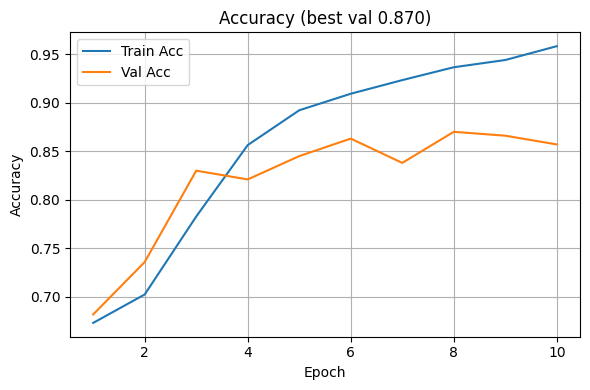

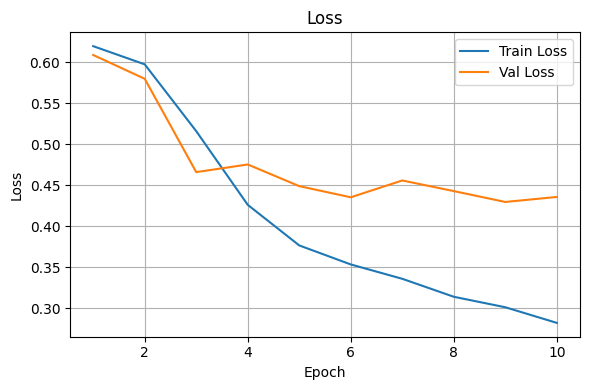

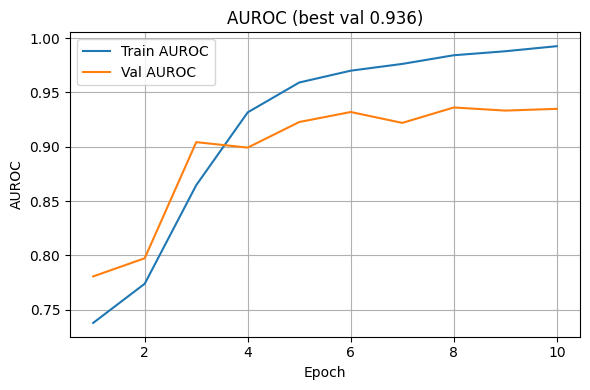

Saved plots locally to: artifacts/plots
Backed up plots to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121/artifacts/plots


In [11]:
# =========================
# CELL 6: Curves (train vs val) + Drive backup (fixed)
# =========================
import matplotlib.pyplot as plt
from pathlib import Path
import shutil

if "history" not in globals() or len(history.get("train", [])) == 0:
    print("No history in memory. If you restarted runtime, rerun Cell 5 to regenerate curves.")
else:
    tr_acc = [x[1] for x in history["train"]]
    va_acc = [x[1] for x in history["val"]]
    tr_loss = [x[0] for x in history["train"]]
    va_loss = [x[0] for x in history["val"]]
    tr_auroc = [x[3] for x in history["train"]]
    va_auroc = [x[3] for x in history["val"]]
    epochs = range(1, len(tr_acc) + 1)

    # local output
    out_dir = ARTIFACTS_DIR / "plots"
    out_dir.mkdir(parents=True, exist_ok=True)

    # drive output
    drive_plots_dir = DRIVE_ARTIFACTS_DIR / "plots"
    drive_plots_dir.mkdir(parents=True, exist_ok=True)

    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, tr_acc, label="Train Acc")
    plt.plot(epochs, va_acc, label="Val Acc")
    plt.title(f"Accuracy (best val {max(va_acc):.3f})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    acc_png = out_dir / "accuracy.png"
    plt.tight_layout()
    plt.savefig(acc_png, dpi=200)
    plt.show()

    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, tr_loss, label="Train Loss")
    plt.plot(epochs, va_loss, label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    loss_png = out_dir / "loss.png"
    plt.tight_layout()
    plt.savefig(loss_png, dpi=200)
    plt.show()

    # AUROC
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, tr_auroc, label="Train AUROC")
    plt.plot(epochs, va_auroc, label="Val AUROC")
    plt.title(f"AUROC (best val {max(va_auroc):.3f})")
    plt.xlabel("Epoch")
    plt.ylabel("AUROC")
    plt.legend()
    plt.grid(True)
    auc_png = out_dir / "auroc.png"
    plt.tight_layout()
    plt.savefig(auc_png, dpi=200)
    plt.show()

    # Backup to Drive
    for p in [acc_png, loss_png, auc_png]:
        if p.exists():
            shutil.copy2(p, drive_plots_dir / p.name)

    print("Saved plots locally to:", out_dir)
    print("Backed up plots to Drive:", drive_plots_dir)



## 5. Optional: Simple Saliency Map (Captum)

This helps **explain** which pixels most influence the prediction.  
Run after training. Provide a path to a single image.


In [12]:
# =========================
# CELL 7: Load best checkpoint (local first, then Drive fallback)
# =========================
from pathlib import Path
import torch

def load_best_checkpoint():
    local_ckpt = ARTIFACTS_DIR / f"best_{USE_MODEL}.pt"
    drive_ckpt = DRIVE_CKPT_DIR / f"best_{USE_MODEL}.pt"

    if local_ckpt.exists():
        ckpt_path = local_ckpt
    elif drive_ckpt.exists():
        ckpt_path = drive_ckpt
        # restore to local for downstream cells
        ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(ckpt_path, local_ckpt)
        ckpt_path = local_ckpt
    else:
        raise FileNotFoundError("No checkpoint found locally or on Drive. Rerun Cell 5.")

    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)
    m = build_model(ckpt["model_name"], num_classes=2, freeze_backbone=False).to(DEVICE)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    return m, ckpt, ckpt_path

model, ckpt, ckpt_path = load_best_checkpoint()
print("Loaded:", ckpt["model_name"])
print("Checkpoint path:", ckpt_path)
print("Label map:", ckpt.get("label_map"))


Loaded: efficientnet_b0
Checkpoint path: artifacts/best_efficientnet_b0.pt
Label map: {'real': 0, 'fake': 1}


In [40]:
from pathlib import Path

d = Path("/content/drive/MyDrive/datasets/DRAGON/test")

src = d / "fake (1)"
dst = d / "fake"

assert src.exists(), f"Missing: {src}"
assert not dst.exists(), f"{dst} already exists. Rename it first or delete it."

src.rename(dst)
print("Renamed:", src, "->", dst)

print("Now children:", sorted([p.name for p in d.iterdir() if p.is_dir()]))
print("real exists:", (d/"real").exists(), "fake exists:", (d/"fake").exists())


Renamed: /content/drive/MyDrive/datasets/DRAGON/test/fake (1) -> /content/drive/MyDrive/datasets/DRAGON/test/fake
Now children: ['fake', 'real']
real exists: True fake exists: True



## 6. Inference Helper


In [41]:
# =========================
# CELL 8: Cross-dataset eval for Issue #38
# - pick threshold on OpenFake val (max F1)
# - apply same threshold to WildFake and DRAGON
# - save metrics CSV, confusion matrices, ROC curves
# - backup everything to Drive
# =========================
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc

CROSS_DIR = ARTIFACTS_DIR / "cross_dataset"
CROSS_DIR.mkdir(parents=True, exist_ok=True)

@torch.inference_mode()
def collect_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y in loader:
        imgs = imgs.to(DEVICE, non_blocking=False)
        logits = model(imgs)
        probs_fake = torch.softmax(logits, dim=1)[:, FAKE_IDX]
        probs_all.append(probs_fake.detach().cpu().numpy())
        y_all.append(y.numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)

def pick_threshold_on_val(y_prob, y_true):
    thresholds = np.linspace(0.0, 1.0, 501)
    best_t, best_score = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return float(best_t), float(best_score)

def eval_with_threshold(y_prob, y_true, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return float(acc), float(f1), float(auroc), cm

def save_confusion_matrix(cm, title, out_path):
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["real(0)", "fake(1)"])
    plt.yticks([0, 1], ["real(0)", "fake(1)"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def save_roc_curve(y_prob, y_true, title, out_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

# Dataset paths
DATASETS_ROOT = Path("/content/drive/MyDrive/datasets")
OPENFAKE_VAL_DIR = Path(val_dir)
WILDFAKE_VAL_DIR = DATASETS_ROOT / "wildfake_2k_split" / "test"
DRAGON_VAL_DIR   = DATASETS_ROOT / "DRAGON" / "test"

for d in [WILDFAKE_VAL_DIR, DRAGON_VAL_DIR]:
    assert d.exists(), f"Missing folder: {d}"
    assert (d / "real").exists() and (d / "fake").exists(), f"{d} must contain real/ and fake/"

# Choose threshold on OpenFake val
a_val_ds = imagefolder_fixed_labels(OPENFAKE_VAL_DIR, transform=val_tfms)
a_val_loader = DataLoader(a_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

y_prob_A, y_raw_A = collect_probs(model, a_val_loader)
y_true_A = (y_raw_A == FAKE_IDX).astype(int)

best_t, best_f1 = pick_threshold_on_val(y_prob_A, y_true_A)
print(f"Chosen threshold on OpenFake val (max F1): t={best_t:.3f} (F1={best_f1:.3f})")

datasets_to_eval = [
    ("A(OpenFake)", OPENFAKE_VAL_DIR),
    ("B(wildfake_2k_split)", WILDFAKE_VAL_DIR),
    ("C(DRAGON)", DRAGON_VAL_DIR),
]

rows = []
for tag, split_path in datasets_to_eval:
    ds = imagefolder_fixed_labels(split_path, transform=val_tfms)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=False)

    y_prob, y_raw = collect_probs(model, loader)
    y_true = (y_raw == FAKE_IDX).astype(int)

    acc, f1, auroc, cm = eval_with_threshold(y_prob, y_true, threshold=best_t)

    rows.append({
        "dataset": tag,
        "n": len(ds),
        "threshold": best_t,
        "acc": acc,
        "f1": f1,
        "auroc": None if np.isnan(auroc) else auroc,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

    cm_path = CROSS_DIR / f"{tag}_confusion_matrix.png"
    roc_path = CROSS_DIR / f"{tag}_roc.png"
    save_confusion_matrix(cm, f"{tag} Confusion Matrix (t={best_t:.3f})", cm_path)
    save_roc_curve(y_prob, y_true, f"{tag} ROC Curve", roc_path)

metrics_df = pd.DataFrame(rows)
display(metrics_df)

metrics_csv = CROSS_DIR / "cross_dataset_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)

note_path = CROSS_DIR / "threshold_note.txt"
note_path.write_text(
    f"Threshold chosen on OpenFake validation by maximizing F1: t={best_t:.3f} (F1={best_f1:.3f}).\n"
    "Same threshold applied unchanged to wildfake_2k_split and DRAGON.\n"
    "Label mapping enforced as 0=real and 1=fake.\n"
)

print("Saved:", metrics_csv)
print("Saved:", note_path)
print("Saved plots in:", CROSS_DIR)

# Backup whole cross_dataset folder to Drive
DRIVE_CROSS_DIR = DRIVE_ARTIFACTS_DIR / "cross_dataset"
if DRIVE_CROSS_DIR.exists():
    shutil.rmtree(DRIVE_CROSS_DIR)
shutil.copytree(CROSS_DIR, DRIVE_CROSS_DIR)
print("Backed up cross-dataset artifacts to Drive:", DRIVE_CROSS_DIR)


Chosen threshold on OpenFake val (max F1): t=0.662 (F1=0.886)


,dataset,n,threshold,acc,f1,auroc,tn,fp,fn,tp
0,A(OpenFake),1000,0.662,0.881000,0.886342,0.936120,417,61,58,464
1,B(wildfake_2k_split),400,0.662,0.547500,0.475362,0.501875,137,63,118,82
2,C(DRAGON),188,0.662,0.978723,0.989011,0.989071,4,1,3,180


Saved: artifacts/cross_dataset/cross_dataset_metrics.csv
Saved: artifacts/cross_dataset/threshold_note.txt
Saved plots in: artifacts/cross_dataset
Backed up cross-dataset artifacts to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121/artifacts/cross_dataset


In [35]:
from pathlib import Path
import os

d = Path("/content/drive/MyDrive/datasets/DRAGON/test")

print("DRAGON/test exists:", d.exists(), "| is_dir:", d.is_dir())
print("CWD:", os.getcwd())

if d.exists():
    print("DRAGON/test children:", sorted([p.name for p in d.iterdir()]))
    print("real exists:", (d/"real").exists(), "| is_dir:", (d/"real").is_dir())
    print("fake exists:", (d/"fake").exists(), "| is_dir:", (d/"fake").is_dir())

    # show a couple image files under each
    for cls in ["real", "fake"]:
        cls_dir = d/cls
        if cls_dir.exists():
            imgs = []
            for ext in ["*.png","*.jpg","*.jpeg","*.webp"]:
                imgs += list(cls_dir.glob(ext))
            print(cls, "image count:", len(imgs), "example:", imgs[0] if imgs else None)
else:
    # show what *does* exist
    base = Path("/content/drive/MyDrive/datasets/DRAGON")
    print("DRAGON exists:", base.exists())
    if base.exists():
        print("DRAGON children:", sorted([p.name for p in base.iterdir()])[:50])


DRAGON/test exists: True | is_dir: True
CWD: /content
DRAGON/test children: ['fake (1)', 'real']
real exists: True | is_dir: True
fake exists: False | is_dir: False
real image count: 5 example: /content/drive/MyDrive/datasets/DRAGON/test/real/test_fake_0000002.png



## 7. Record Results (Fill After Training)

- **Backbone:** EfficientNet-B0 or ResNet-50  
- **Freeze > Unfreeze epoch:** e.g., 1–2 epochs frozen, unfreeze at 3  
- **Val Accuracy:** …  
- **Val F1:** …  
- **Val AUROC:** …  
- **Observations:** … (e.g., overfitting signs, which backbone worked better, any class imbalance tweaks)

> Tip: If your dataset is imbalanced, consider using `WeightedRandomSampler` or class weights in `CrossEntropyLoss`.


In [42]:
# =========================
# CELL 9: Export artifacts for Issue #42 (and back up to Drive)
# Exports:
# - model.pth
# - config.json (includes threshold)
# - preprocess.json
# - label_map.json
# - README.md
# =========================
import os, json
from datetime import datetime

EXPORT_DIR = Path("export/cnn-transfer")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save weights (state_dict only)
torch.save(model.state_dict(), EXPORT_DIR / "model.pth")

preprocess = {
    "input_size": [IM_SIZE, IM_SIZE],
    "resize": {"enabled": True, "size": [IM_SIZE, IM_SIZE]},
    "center_crop": {"enabled": False},
    "normalize": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
    "notes": "Resize to IM_SIZE x IM_SIZE then normalize with ImageNet mean/std."
}

label_map = {"0": "real", "1": "fake"}

config = {
    "name": "cnn-transfer",
    "framework": "pytorch",
    "arch": USE_MODEL,
    "num_classes": 2,
    "threshold": float(best_t) if "best_t" in globals() else 0.50,
    "labels": label_map,
    "exported_at_utc": datetime.utcnow().isoformat() + "Z",
    "notes": "CNN transfer baseline for deepfake detection. prob_fake = softmax(logits)[fake]."
}

readme = f"""---
license: apache-2.0
tags:
  - image-classification
  - deepfake-detection
  - pytorch
---

# CNN Transfer (DeepFakeDetector)

Binary image classifier for deepfake or AI-generated image detection.

## Label convention (fixed)
- 0 = real
- 1 = fake

## Preprocessing
- Resize to {IM_SIZE}x{IM_SIZE}
- Normalize with ImageNet mean/std

## Output
- prob_fake in [0, 1] computed as softmax(logits)[fake]
- decision threshold: {config["threshold"]:.3f}
"""

with open(EXPORT_DIR / "preprocess.json", "w") as f:
    json.dump(preprocess, f, indent=2)
with open(EXPORT_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)
with open(EXPORT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)
with open(EXPORT_DIR / "README.md", "w") as f:
    f.write(readme)

print("Exported files:", sorted([p.name for p in EXPORT_DIR.iterdir()]))

# Backup export folder to Drive
DRIVE_EXPORT_DIR = DRIVE_RUN_DIR / "export" / "cnn-transfer"
if DRIVE_EXPORT_DIR.exists():
    shutil.rmtree(DRIVE_EXPORT_DIR)
shutil.copytree(EXPORT_DIR, DRIVE_EXPORT_DIR)
print("Backed up export folder to Drive:", DRIVE_EXPORT_DIR)


Exported files: ['README.md', 'config.json', 'label_map.json', 'model.pth', 'preprocess.json']
Backed up export folder to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121/export/cnn-transfer


/tmp/ipython-input-105710457.py:36: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "exported_at_utc": datetime.utcnow().isoformat() + "Z",



## 8. (Optional) Write a `requirements.txt`

Run this cell once to generate a minimal `requirements.txt` alongside artifacts.


In [43]:
# =========================
# CELL 10: Install Hugging Face hub client (safe to run)
# =========================
%pip -q install huggingface_hub


In [44]:
import os, getpass

os.environ["HF_TOKEN_WRITE"] = getpass.getpass("Paste your Hugging Face WRITE token (input hidden): ")
print("HF_TOKEN_WRITE set for this runtime:", "yes" if os.environ.get("HF_TOKEN_WRITE") else "no")


Paste your Hugging Face WRITE token (input hidden): ··········
HF_TOKEN_WRITE set for this runtime: yes


In [45]:
# =========================
# CELL 11: Upload export folder to Hugging Face (Issue #42)
# Requires env var: HF_TOKEN_WRITE
# =========================
import os
from huggingface_hub import HfApi

REPO_ID = "DeepFakeDetector/cnn-transfer"
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE")
assert HF_TOKEN, "Missing HF_TOKEN_WRITE. Set it in your environment (do not commit it)."

api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path=str(EXPORT_DIR),
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="Upload CNN transfer artifacts (model + preprocess + config)"
)

print(f"Uploaded to https://huggingface.co/{REPO_ID}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rt/cnn-transfer/model.pth: 100%|##########| 16.3MB / 16.3MB            

Uploaded to https://huggingface.co/DeepFakeDetector/cnn-transfer


In [46]:
import os
from huggingface_hub import whoami

tok = os.environ.get("HF_TOKEN_WRITE")
print("HF_TOKEN_WRITE set:", bool(tok))
print("Token starts with:", tok[:8] + "..." if tok else None)

print("whoami:", whoami(token=tok))


HF_TOKEN_WRITE set: True
Token starts with: hf_kmlMd...
whoami: {'type': 'user', 'id': '69741c1471f36b2a96dc5db2', 'name': 'alifiscool86', 'fullname': 'Md Nafieu Hossain Alif', 'email': 'nafieu.alif@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1772323200, 'isPro': False, 'avatarUrl': '/avatars/fd79f39be30362b47b440060c7101194.svg', 'orgs': [{'type': 'org', 'id': '69877d9278a9e474fea8bc48', 'name': 'DeepFakeDetector', 'fullname': 'DeepFake Detector - MacAI Society', 'email': 'lukhsaankumar@gmail.com', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1772323200, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/69877c9cd590f31fe07578cd/6IhAoE1DNJ6o6MWPkNbP9.jpeg', 'roleInOrg': 'write', 'isEnterprise': False}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'deepfake', 'role': 'write', 'createdAt': '2026-02-16T22:38:33.586Z'}}}


In [24]:
# =========================
# CELL 12: Reload test (download snapshot -> load -> 1 inference)
# Deterministic + token-safe + does not rely on earlier vars except build_model
# Saves a note to Drive if DRIVE_RUN_DIR exists
# =========================

import os, json
from pathlib import Path
import torch
from huggingface_hub import snapshot_download
from PIL import Image

REPO_ID = "DeepFakeDetector/cnn-transfer"

# 1) Download snapshot with auth (works for private + avoids 401)
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE") or os.environ.get("HF_TOKEN")
assert HF_TOKEN, "Missing HF token in env. Set HF_TOKEN_WRITE before running reload test."

local_repo = Path(snapshot_download(
    repo_id=REPO_ID,
    repo_type="model",
    token=HF_TOKEN
))
print("Downloaded snapshot to:", local_repo)

# 2) Load config + preprocess
with open(local_repo / "config.json", "r") as f:
    cfg = json.load(f)

with open(local_repo / "preprocess.json", "r") as f:
    pp = json.load(f)

with open(local_repo / "label_map.json", "r") as f:
    label_map = json.load(f)

# Enforce label convention: 0 real, 1 fake
assert label_map.get("0") == "real" and label_map.get("1") == "fake", f"Bad label_map.json: {label_map}"

# 3) Rebuild model exactly
arch = cfg["arch"]
reload_model = build_model(arch, num_classes=2, freeze_backbone=False).to("cpu")

state = torch.load(local_repo / "model.pth", map_location="cpu")
reload_model.load_state_dict(state)
reload_model.eval()

# 4) Prepare one sample image
# Prefer using your existing OpenFake val sample if available, else try to find any local image in datasets
sample_path = None

# Case A: if val_dir is defined earlier (OpenFake val folder), pick the first available image
try:
    if "val_dir" in globals():
        for cls in ["real", "fake"]:
            cand_dir = Path(val_dir) / cls
            if cand_dir.exists():
                imgs = sorted([p for p in cand_dir.glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png",".webp"]])
                if imgs:
                    sample_path = str(imgs[0])
                    break
except Exception:
    pass

# Fallback: search common dataset locations
if sample_path is None:
    for base in [Path("datasets"), Path("/content/datasets"), Path("/content/drive/MyDrive/datasets")]:
        if base.exists():
            imgs = list(base.rglob("*.jpg")) + list(base.rglob("*.png")) + list(base.rglob("*.jpeg")) + list(base.rglob("*.webp"))
            if imgs:
                sample_path = str(sorted(imgs)[0])
                break

assert sample_path is not None, "Could not find any image file for inference test."

# 5) Apply preprocess using pp info but reuse your val_tfms if it exists (keeps consistent pipeline)
# If val_tfms exists, use it. Otherwise, build a minimal transform from preprocess.json.
try:
    x = val_tfms(Image.open(sample_path).convert("RGB")).unsqueeze(0)
except Exception:
    from torchvision import transforms
    mean = pp["normalize"]["mean"]
    std  = pp["normalize"]["std"]
    size = int(pp["input_size"])
    # center_crop is optional in pp; keep resize only for baseline
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    x = tfm(Image.open(sample_path).convert("RGB")).unsqueeze(0)

x = x.to("cpu")

# 6) Inference
with torch.no_grad():
    logits = reload_model(x)
    prob_fake = torch.softmax(logits, dim=1)[0, 1].item()  # index 1 == fake (fixed)

thr = float(cfg.get("threshold", 0.5))
pred = 1 if prob_fake >= thr else 0

print("Sample:", sample_path)
print("prob_fake:", prob_fake)
print("threshold:", thr)
print("pred:", pred, "(0=real,1=fake)")
print("Reload test OK.")

# 7) Save a small note in Drive if available
try:
    if "DRIVE_RUN_DIR" in globals():
        Path(DRIVE_RUN_DIR).mkdir(parents=True, exist_ok=True)
        (Path(DRIVE_RUN_DIR) / "hf_reload_note.txt").write_text(
            f"snapshot_download path: {local_repo}\n"
            f"sample: {sample_path}\n"
            f"prob_fake: {prob_fake}\n"
            f"threshold: {thr}\n"
            f"pred: {pred}\n"
        )
        print("Saved reload note to Drive:", Path(DRIVE_RUN_DIR) / "hf_reload_note.txt")
except Exception as e:
    print("Drive note save skipped:", e)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Downloaded snapshot to: /root/.cache/huggingface/hub/models--DeepFakeDetector--cnn-transfer/snapshots/ab91377ac7df5aaa85f92d290b6a7583865b518b
Sample: /content/drive/MyDrive/datasets/OpenFake/test/real/test_0000002.jpg
prob_fake: 0.01156085729598999
threshold: 0.662
pred: 0 (0=real,1=fake)
Reload test OK.
Saved reload note to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121/hf_reload_note.txt


In [47]:
# =========================
# CELL 13: Final status summary
# =========================
print("Local best checkpoint:", best_path if best_path.exists() else "missing")
print("Drive run folder:", DRIVE_RUN_DIR)

print("Drive checkpoints:", [p.name for p in DRIVE_CKPT_DIR.glob("*.pt")])
print("Drive artifacts:", [p.name for p in DRIVE_ARTIFACTS_DIR.glob("*") if p.is_file()])
print("Drive export:", DRIVE_EXPORT_DIR if "DRIVE_EXPORT_DIR" in globals() else "not created yet")
print("If upload succeeded, HF repo should contain: model.pth, config.json, preprocess.json, label_map.json, README.md")


Local best checkpoint: artifacts/best_efficientnet_b0.pt
Drive run folder: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121
Drive checkpoints: ['best_efficientnet_b0.pt']
Drive artifacts: ['history.json', 'history.csv', 'cross_dataset_metrics.csv', 'threshold_note.txt']
Drive export: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260216_224121/export/cnn-transfer
If upload succeeded, HF repo should contain: model.pth, config.json, preprocess.json, label_map.json, README.md
